# Notebook 9: Meningitis Dataset with Missing Values (Kaggle)
**Fuente:** https://www.kaggle.com/datasets/chantest/meningitis-dataset-with-missing-values

Dataset clínico de meningitis con valores faltantes. Contiene variables de laboratorio y clínicas para clasificar el tipo de meningitis (bacteriana vs viral) o predecir desenlaces.

##  Introducción
El **Meningitis Dataset** contiene registros clínicos de pacientes con meningitis, incluyendo parámetros de líquido cefalorraquídeo (LCR), valores de laboratorio en sangre y síntomas. La alta tasa de valores faltantes es una característica central del dataset. El objetivo típico es **clasificar el tipo de meningitis** (bacteriana vs viral) o predecir la evolución del paciente. Se trata de un problema de **clasificación binaria/multiclase**.

##  Carga del Dataset
Descarga el archivo `meningitis.csv` desde Kaggle y súbelo a Google Drive o al entorno local.

In [2]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Entorno local detectado.')

if IN_COLAB:
    DATA_PATH   = '/content/drive/MyDrive/datasets/meningitis.csv'
    EXPORT_PATH = '/content/drive/MyDrive/datasets/output/'
else:
    DATA_PATH   = 'meningitis.csv'
    EXPORT_PATH = './meningitis_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Mounted at /content/drive
Dataset cargado: 1200 filas x 14 columnas


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


## Identificación del Tipo de Problema

In [3]:
print('Columnas disponibles:')
print(df.columns.tolist())

# Detectar columna objetivo
posibles_targets = [c for c in df.columns if any(kw in c.lower() for kw in ['type','diagnosis','class','label','outcome','result','group'])]
TARGET = posibles_targets[0] if posibles_targets else df.columns[-1]
print(f'\nVariable objetivo identificada: {TARGET}')
print(f'Valores únicos: {df[TARGET].unique()}')
print(f'Distribución:\n{df[TARGET].value_counts()}')
n_classes = df[TARGET].nunique()
prob_type = 'CLASIFICACIÓN BINARIA' if n_classes == 2 else f'CLASIFICACIÓN MULTICLASE ({n_classes} clases)'
print(f'\n→ Tipo de problema: {prob_type}')

Columnas disponibles:
['Patient_ID', 'Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level', 'Risk_Level']

Variable objetivo identificada: Diagnosis
Valores únicos: ['Viral' 'Unknown' 'Bacterial' nan]
Distribución:
Diagnosis
Viral        565
Bacterial    499
Unknown      124
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN MULTICLASE (3 clases)


##  Análisis Exploratorio (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Info general ===')
df.info()
print('\n=== Estadísticas descriptivas ===')
display(df.describe())

=== Info general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1193 non-null   float64
 2   Gender            1191 non-null   object 
 3   WBC_Count         1192 non-null   float64
 4   Protein_Level     1190 non-null   float64
 5   Glucose_Level     1192 non-null   float64
 6   Pathogen_Present  1192 non-null   object 
 7   Diagnosis         1188 non-null   object 
 8   Outcome           1190 non-null   object 
 9   Hemoglobin        1181 non-null   float64
 10  WBC_Blood_Count   1190 non-null   float64
 11  Platelets         1188 non-null   float64
 12  CRP_Level         1187 non-null   float64
 13  Risk_Level        1200 non-null   object 
dtypes: float64(8), int64(1), object(5)
memory usage: 131.4+ KB

=== Estadísticas descriptivas ===


,Patient_ID,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level
count,1200.000000,1193.000000,1192.000000,1190.000000,1192.000000,1181.000000,1190.000000,1188.000000,1187.000000
mean,600.500000,47.432523,12130.966443,109.463866,52.633389,9.998307,11295.922689,201626.741582,27.497051
std,346.554469,24.571305,5670.489634,72.122291,34.695494,5.577193,4956.524846,90936.534040,26.373065
min,1.000000,0.000000,2017.000000,0.000000,0.000000,1.000000,4013.000000,100204.000000,0.000000
25%,300.750000,29.000000,7007.250000,43.000000,26.000000,5.000000,6746.750000,125491.250000,3.000000
50%,600.500000,43.000000,12282.000000,108.000000,53.000000,12.000000,9782.500000,161890.500000,25.000000
75%,900.250000,61.000000,16895.750000,167.000000,66.000000,15.000000,15806.250000,275962.250000,42.000000
max,1200.000000,119.000000,24947.000000,297.000000,149.000000,18.000000,19988.000000,399110.000000,99.000000


In [5]:
# Análisis de valores faltantes (característica central de este dataset)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Pct': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)
print(f'Columnas con valores faltantes: {len(missing_df)}')
display(missing_df)

Columnas con valores faltantes: 12


,Missing_Count,Missing_Pct
Hemoglobin,19,1.58
CRP_Level,13,1.08
Platelets,12,1.00
Diagnosis,12,1.00
Outcome,10,0.83
WBC_Blood_Count,10,0.83
Protein_Level,10,0.83
Gender,9,0.75
Glucose_Level,8,0.67
WBC_Count,8,0.67


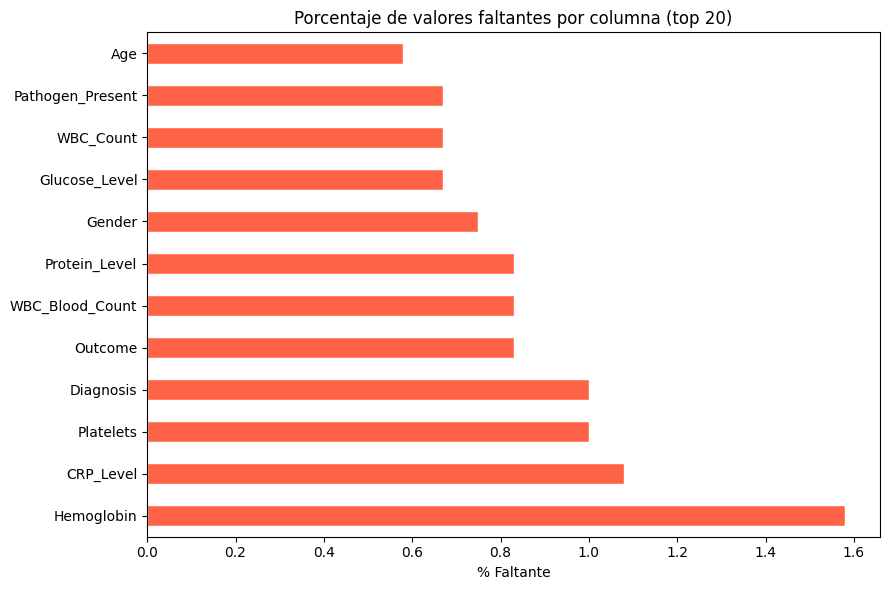

In [6]:
# Visualización de missing values
if len(missing_df) > 0:
    missing_df['Missing_Pct'].head(20).plot(kind='barh', color='tomato', edgecolor='white', figsize=(9,6))
    plt.title('Porcentaje de valores faltantes por columna (top 20)')
    plt.xlabel('% Faltante')
    plt.tight_layout()
    plt.show()

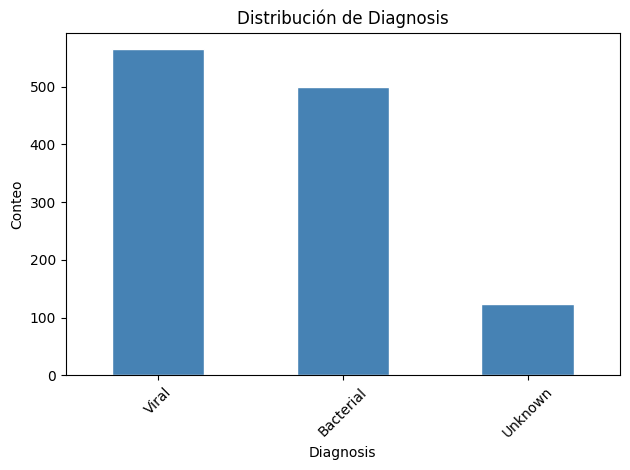

In [7]:
# Distribución de clases
df[TARGET].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Distribución de {TARGET}')
plt.xticks(rotation=45)
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

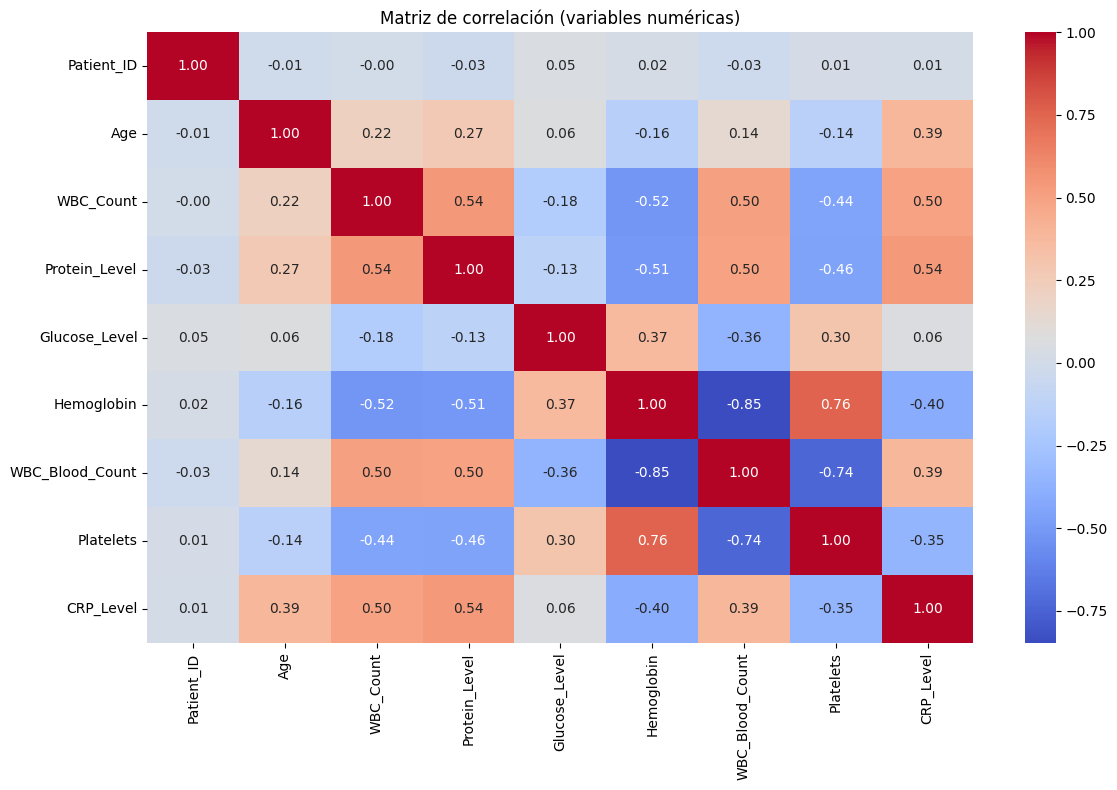

In [8]:
# Correlaciones entre variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    plt.figure(figsize=(12,8))
    sns.heatmap(df[num_cols].corr(), annot=len(num_cols) <= 12, fmt='.2f', cmap='coolwarm')
    plt.title('Matriz de correlación (variables numéricas)')
    plt.tight_layout()
    plt.show()

##  Limpieza y Preparación
Dado que este dataset tiene alta tasa de valores faltantes, se aplica una estrategia de imputación robusta en lugar de eliminación masiva.

In [9]:
df_clean = df.copy()

# Eliminar duplicados
print(f'Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Eliminar columnas con >70% de valores faltantes (demasiado poco dato para imputar)
threshold = 0.70
missing_ratio = df_clean.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
if TARGET in cols_to_drop:
    cols_to_drop.remove(TARGET)
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'Columnas eliminadas por >70% missing: {cols_to_drop}')

# Eliminar filas sin target
df_clean = df_clean.dropna(subset=[TARGET])

# Re-detectar tipos
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Imputar numéricos con mediana
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Imputar categóricos con moda
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')
print(f'Shape final: {df_clean.shape}')

Duplicados: 0
Columnas eliminadas por >70% missing: []
Nulos restantes: 0
Shape final: (1188, 14)


/tmp/ipykernel_2154/986614851.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_2154/986614851.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [10]:
# Tratamiento de outliers en columnas numéricas (clip con 3*IQR)
for col in num_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        outliers_count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        if outliers_count > 0:
            df_clean[col] = df_clean[col].clip(lower, upper)
            print(f'  {col}: {outliers_count} outliers suavizados')

print(f'Shape tras outliers: {df_clean.shape}')

Shape tras outliers: (1188, 14)


## Transformación y Preprocesamiento

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_clean.copy()

# Codificar target
le_target = LabelEncoder()
df_processed[TARGET] = le_target.fit_transform(df_processed[TARGET].astype(str))
print(f'Clases codificadas: {dict(enumerate(le_target.classes_))}')

# Redetectar tras limpieza
cat_cols_proc = df_processed.select_dtypes(include=['object']).columns.tolist()
num_cols_proc = [c for c in df_processed.select_dtypes(include=[np.number]).columns if c != TARGET]

le = LabelEncoder()
for col in cat_cols_proc:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

scaler = StandardScaler()
if num_cols_proc:
    df_processed[num_cols_proc] = scaler.fit_transform(df_processed[num_cols_proc])

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Clases codificadas: {0: 'Bacterial', 1: 'Unknown', 2: 'Viral'}
Shape preprocesado: (1188, 14)


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,-1.757567,2.178881,0,-0.622609,-1.302297,0.879241,0,2,1,0.897906,-0.814125,-0.447517,1.655197,2
1,-1.754660,1.242622,1,1.856526,1.263515,-0.337461,0,1,1,1.440211,-0.963188,1.877958,0.513240,0
2,-1.751754,-1.606860,0,0.136061,-0.981571,-1.438286,0,1,1,1.078674,-0.784191,-0.232899,-0.210000,2
3,-1.748848,2.301002,0,0.519292,-0.716623,-0.482306,1,0,1,-0.548239,0.505201,-0.764083,0.779697,2
4,-1.745942,-0.385653,0,1.148151,0.594173,-0.540244,1,0,1,-0.909775,1.164965,-0.734440,0.018392,0


## División Train/Test (80/20, stratify si aplica)

In [12]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

# Usar stratify si todas las clases tienen al menos 2 muestras
min_class_count = y.value_counts().min()
use_stratify = min_class_count >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y if use_stratify else None
)

print(f'Stratify aplicado: {use_stratify}')
train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Distribución de clases en train:\n{y_train.value_counts()}')
print(f'Distribución de clases en test:\n{y_test.value_counts()}')

Stratify aplicado: True
Train: (950, 14)  |  Test: (238, 14)
Distribución de clases en train:
Diagnosis
2    452
0    399
1     99
Name: count, dtype: int64
Distribución de clases en test:
Diagnosis
2    113
0    100
1     25
Name: count, dtype: int64


##  Exportación de train.csv y test.csv

In [13]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado en: {EXPORT_PATH}  ({train_df.shape[0]} filas, {train_df.shape[1]} columnas)')
print(f'✅ test.csv  guardado en: {EXPORT_PATH}  ({test_df.shape[0]} filas, {test_df.shape[1]} columnas)')
print(f'\nClases decodificadas: {dict(enumerate(le_target.classes_))}')

✅ train.csv guardado en: /content/drive/MyDrive/datasets/output/  (950 filas, 14 columnas)
✅ test.csv  guardado en: /content/drive/MyDrive/datasets/output/  (238 filas, 14 columnas)

Clases decodificadas: {0: 'Bacterial', 1: 'Unknown', 2: 'Viral'}
